In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import cortico_cereb_connectivity.summarize as summarize

#### import the .tsv files to plot

In [7]:
df_L2reg = pd.read_csv('../../tsv/L2reg_heatmap.tsv', sep='\t')
df_NNLS = pd.read_csv('../../tsv/NNLS_heatmap.tsv', sep='\t')
df_diff = pd.read_csv('../../tsv/Diff_heatmap.tsv', sep='\t')
df_all = pd.concat([df_L2reg, df_NNLS], axis=0).reset_index(drop=True)

pivot_L2reg = df_L2reg.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')
pivot_NNLS = df_NNLS.pivot(index=['eval_dataset', 'eval_subj'], columns='train_dataset', values='R_eval_adj')
pivot_all = df_all.pivot(index=["eval_dataset", "eval_subj"], 
                          columns=["train_dataset", "method"], values="R_eval_adj")
pivot_dataset = df_all.pivot_table(index="eval_dataset", columns=["train_dataset", "method"], values="R_eval_adj", aggfunc='mean')


ds_order = ["MDTB", "Language", "Social", "WMFS", "Demand", "Somatotopic", "Nishimoto", "IBC", "HCPur100"]

save_plots = False

In [8]:
# Load the best models
best_models_L2reg, _ = summarize.get_model(''.join(gl.dscode), "Icosahedron1002", "L2reg", "A2_global")
best_models_NNLS, _ = summarize.get_model(''.join(gl.dscode), "Icosahedron1002", "NNLS", "A0_global")

w_nnls = np.ravel(best_models_NNLS.coef_)
w_ridge = np.ravel(best_models_L2reg.coef_)

def cdf_curve(w):
    w = np.ravel(w)
    x = np.sort(w)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_r, y_r = cdf_curve(w_ridge)
x_n, y_n = cdf_curve(w_nnls)

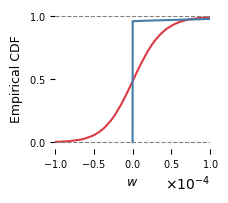

In [5]:
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.figure(figsize=(2, 1.8))

ax = plu.plot_emp_CDF(x_r, y_r, x_n, y_n)
ax.set_xlim(-1e-4, 1e-4)
ax.set_ylabel('Empirical CDF', fontsize=9)
ax.set_xlabel(r'$w$', fontsize=9)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.yticks([0, 0.5, 1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine(left=True, bottom=True)
ax.tick_params(labelsize=7)

if save_plots:
    plt.savefig(gl.fig_dir + "/fig02_a.pdf", bbox_inches="tight", dpi=300)

Threshold weights to see what percentage is bigger that Thr

In [11]:
threshold = 1e-7
percent_ridge = np.sum(np.abs(w_ridge) > threshold) / len(w_ridge) * 100
percent_nnls = np.sum(np.abs(w_nnls) > threshold) / len(w_nnls) * 100

print(f'Percent of non-zero weights (Ridge): {percent_ridge:.2f}%')
print(f'Percent of non-zero weights (NNLS): {percent_nnls:.2f}%')

Percent of non-zero weights (Ridge): 99.74%
Percent of non-zero weights (NNLS): 3.96%
